In [1]:
"""
Yield Curve Loader and Cleaner
-------------------------------
Loads GT1, GT2, GT3, GT5, GT7, GT10 Bloomberg exports,
combines into a single daily yield curve table,
interpolates to any maturity, and saves to clean folder.
"""

import pandas as pd
import numpy as np
import os

# ── Paths ──────────────────────────────────────────────────────────────────
BASE_DIR   = r"C:\Users\sarda\Desktop\convertible_arb"
YIELD_DIR  = os.path.join(BASE_DIR, "data", "raw", "yields")
CLEAN_DIR  = os.path.join(BASE_DIR, "data", "clean")
os.makedirs(CLEAN_DIR, exist_ok=True)

# ── Tenor map: filename → years ────────────────────────────────────────────
TENOR_MAP = {
    "GT1":  1,
    "GT2":  2,
    "GT3":  3,
    "GT5":  5,
    "GT7":  7,
    "GT10": 10,
}

# ── Step 1: Load each file ─────────────────────────────────────────────────
def load_single_tenor(filename, tenor_years):
    """
    Load one Bloomberg GT xlsx file.
    - Metadata sits in rows 1-5 (0-indexed: 0-4)
    - Row 6 (index 5) is the header: Date | PX_LAST | PX_BID
    - Data runs from row 7 onward (index 6+)
    - Dates are in dd-mm-yyyy format
    - We use PX_LAST as the yield
    """
    filepath = os.path.join(YIELD_DIR, f"{filename}.xlsx")

    df = pd.read_excel(
        filepath,
        header=5,          # row index 5 = row 6 in Excel = our real header
        usecols=[0, 1],    # Date and PX_LAST only
        parse_dates=False  # we handle dates manually
    )

    # Rename columns cleanly
    df.columns = ["Date", f"yield_{tenor_years}y"]

    # Drop any fully empty rows (sometimes Bloomberg adds blank rows at top/bottom)
    df = df.dropna(subset=["Date"])

    # Parse dates — Bloomberg exports as dd-mm-yyyy string or datetime
    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
    df = df.dropna(subset=["Date"])

    # Convert yield to decimal (Bloomberg gives 4.085 meaning 4.085% — keep as-is,
    # we divide by 100 at the end so calculations use 0.04085)
    df[f"yield_{tenor_years}y"] = pd.to_numeric(df[f"yield_{tenor_years}y"], errors="coerce")

    # Sort chronologically (Bloomberg exports newest first)
    df = df.sort_values("Date").reset_index(drop=True)

    print(f"  Loaded {filename}: {len(df)} rows | "
          f"{df['Date'].min().date()} to {df['Date'].max().date()} | "
          f"Missing: {df[f'yield_{tenor_years}y'].isna().sum()}")

    return df


# ── Step 2: Merge all tenors ───────────────────────────────────────────────
def build_yield_curve():
    print("\n[1] Loading yield curve files...")

    merged = None

    for filename, tenor_years in TENOR_MAP.items():
        df = load_single_tenor(filename, tenor_years)

        if merged is None:
            merged = df
        else:
            merged = pd.merge(merged, df, on="Date", how="outer")

    # Sort by date after outer merge
    merged = merged.sort_values("Date").reset_index(drop=True)

    print(f"\n  Combined shape: {merged.shape}")
    print(f"  Date range: {merged['Date'].min().date()} to {merged['Date'].max().date()}")

    return merged


# ── Step 3: Clean ──────────────────────────────────────────────────────────
def clean_yield_curve(df):
    print("\n[2] Cleaning yield curve...")

    # Keep only weekdays (drop any accidental weekend rows)
    df = df[df["Date"].dt.dayofweek < 5].copy()

    # Create a complete weekday date index across the full range
    full_index = pd.bdate_range(start=df["Date"].min(), end=df["Date"].max())
    df = df.set_index("Date").reindex(full_index)
    df.index.name = "Date"

    # Count missing before fill
    missing_before = df.isna().sum()

    # Forward fill missing yields (Treasury market closed on holidays — carry prior day)
    df = df.ffill()

    # If any gaps remain at the very start, back fill
    df = df.bfill()

    missing_after = df.isna().sum()

    print(f"  Missing values before fill: \n{missing_before}")
    print(f"  Missing values after fill:  \n{missing_after}")

    # Convert yields from percentage to decimal (4.085 → 0.04085)
    yield_cols = [c for c in df.columns if c.startswith("yield_")]
    df[yield_cols] = df[yield_cols] / 100

    df = df.reset_index()

    print(f"\n  Final shape: {df.shape}")
    print(f"  Sample (last 5 rows):\n{df.tail()}")

    return df


# ── Step 4: Interpolation function ────────────────────────────────────────
def interpolate_yield(df_yields, date, maturity_years):
    """
    Given a specific date and remaining maturity in years,
    linearly interpolate the Treasury yield from the curve.

    Parameters:
        df_yields      : cleaned yield curve dataframe (output of clean_yield_curve)
        date           : the date you want the yield for (datetime or string)
        maturity_years : remaining maturity of the bond in years (float, e.g. 2.3)

    Returns:
        interpolated yield as a decimal (e.g. 0.0457 for 4.57%)
    """
    TENORS = [1, 2, 3, 5, 7, 10]

    # Get the yield row for this date
    date = pd.to_datetime(date)
    row = df_yields[df_yields["Date"] == date]

    if row.empty:
        # Use nearest available date
        idx = (df_yields["Date"] - date).abs().idxmin()
        row = df_yields.iloc[[idx]]

    yields = {t: row[f"yield_{t}y"].values[0] for t in TENORS}

    # Clamp to curve boundaries
    if maturity_years <= TENORS[0]:
        return yields[TENORS[0]]
    if maturity_years >= TENORS[-1]:
        return yields[TENORS[-1]]

    # Find surrounding tenors
    lower_tenor = max(t for t in TENORS if t <= maturity_years)
    upper_tenor = min(t for t in TENORS if t >= maturity_years)

    if lower_tenor == upper_tenor:
        return yields[lower_tenor]

    # Linear interpolation
    lower_yield = yields[lower_tenor]
    upper_yield = yields[upper_tenor]

    interpolated = lower_yield + (
        (maturity_years - lower_tenor) / (upper_tenor - lower_tenor)
    ) * (upper_yield - lower_yield)

    return interpolated


# ── Step 5: Save ───────────────────────────────────────────────────────────
def save_yield_curve(df):
    output_path = os.path.join(CLEAN_DIR, "yield_curve_clean.csv")
    df.to_csv(output_path, index=False)
    print(f"\n[3] Saved yield_curve_clean.csv → {output_path}")
    return output_path


# ── Step 6: Quick sanity check ─────────────────────────────────────────────
def sanity_check(df):
    print("\n[4] Sanity checks...")

    yield_cols = [c for c in df.columns if c.startswith("yield_")]

    # Check yield ranges (in decimal — should be between 0% and 10%)
    for col in yield_cols:
        min_y = df[col].min()
        max_y = df[col].max()
        print(f"  {col}: min={min_y:.4f} ({min_y*100:.2f}%)  max={max_y:.4f} ({max_y*100:.2f}%)")

        if min_y < 0:
            print(f"    WARNING: Negative yields found in {col} — check data")
        if max_y > 0.15:
            print(f"    WARNING: Yields above 15% found in {col} — check data")

    # Check interpolation works with an example
    test_date = df["Date"].iloc[len(df)//2]  # middle of dataset
    test_maturity = 2.3
    test_yield = interpolate_yield(df, test_date, test_maturity)
    print(f"\n  Interpolation test: date={test_date.date()}, "
          f"maturity={test_maturity}y → yield={test_yield:.4f} ({test_yield*100:.3f}%)")

    # Check normal yield curve shape on a recent date
    recent_date = df["Date"].max()
    print(f"\n  Yield curve on {recent_date.date()}:")
    for tenor in [1, 2, 3, 5, 7, 10]:
        y = df[df["Date"] == recent_date][f"yield_{tenor}y"].values[0]
        print(f"    {tenor:2d}Y : {y*100:.3f}%")


# ── Main ───────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    print("=" * 60)
    print("  YIELD CURVE PIPELINE")
    print("=" * 60)

    # Load
    raw = build_yield_curve()

    # Clean
    clean = clean_yield_curve(raw)

    # Sanity check
    sanity_check(clean)

    # Save
    save_yield_curve(clean)

    print("\nDone. yield_curve_clean.csv is ready for discount rate calculation.")
    print("=" * 60)

  YIELD CURVE PIPELINE

[1] Loading yield curve files...
  Loaded GT1: 1871 rows | 2019-01-02 to 2026-03-04 | Missing: 0
  Loaded GT2: 1869 rows | 2019-01-02 to 2026-03-04 | Missing: 0
  Loaded GT3: 1869 rows | 2019-01-02 to 2026-03-04 | Missing: 0
  Loaded GT5: 1869 rows | 2019-01-02 to 2026-03-04 | Missing: 0
  Loaded GT7: 1869 rows | 2019-01-02 to 2026-03-04 | Missing: 0
  Loaded GT10: 1869 rows | 2019-01-02 to 2026-03-04 | Missing: 0

  Combined shape: (1871, 7)
  Date range: 2019-01-02 to 2026-03-04

[2] Cleaning yield curve...
  Missing values before fill: 
yield_1y     0
yield_2y     2
yield_3y     2
yield_5y     2
yield_7y     2
yield_10y    2
dtype: int64
  Missing values after fill:  
yield_1y     0
yield_2y     0
yield_3y     0
yield_5y     0
yield_7y     0
yield_10y    0
dtype: int64

  Final shape: (1871, 7)
  Sample (last 5 rows):
           Date  yield_1y  yield_2y  yield_3y  yield_5y  yield_7y  yield_10y
1866 2026-02-26  0.035020   0.03431   0.03440   0.03570   0.03764 

Loaded 1871 rows | 2019-01-02 to 2026-03-04


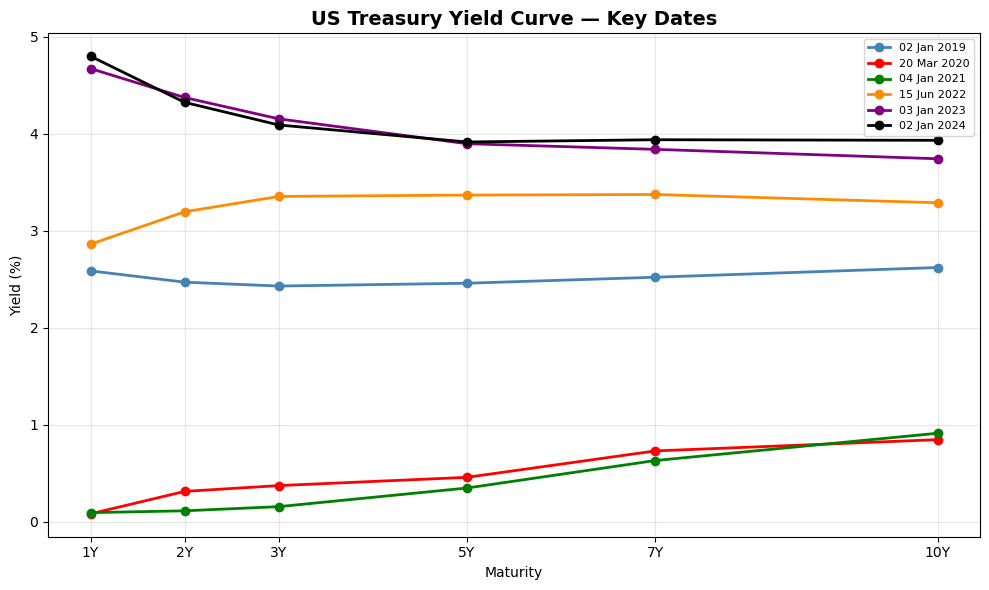

Saved: yield_curve_key_dates.png


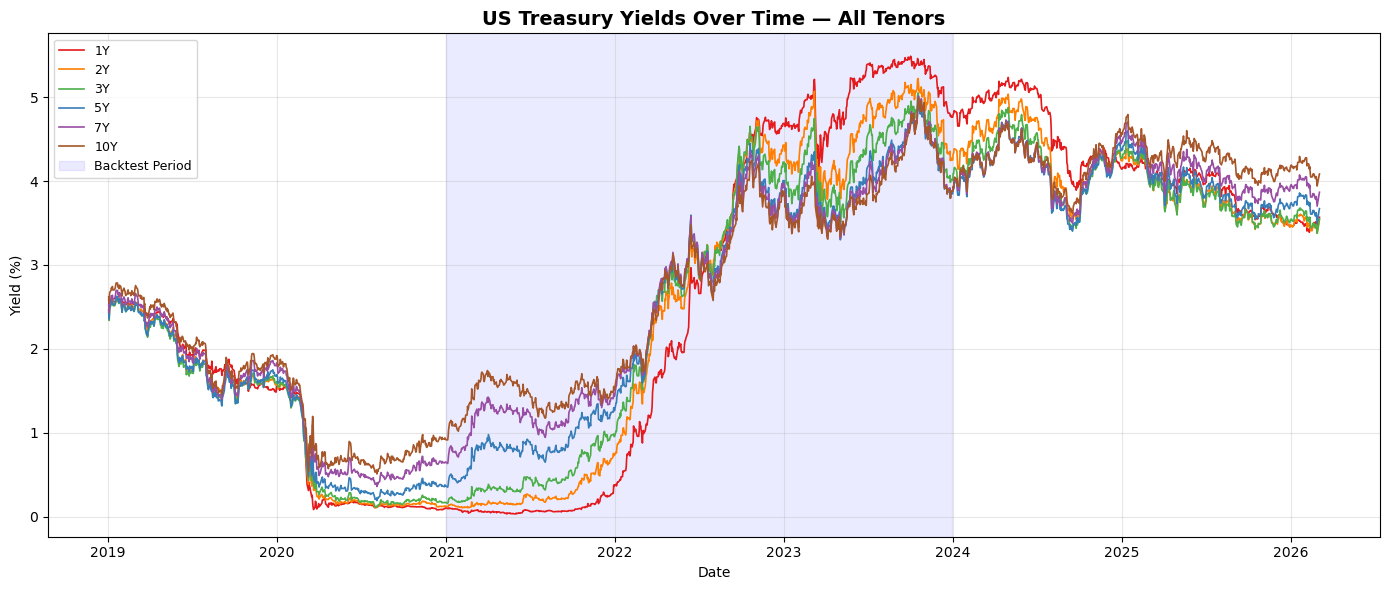

Saved: yields_over_time.png


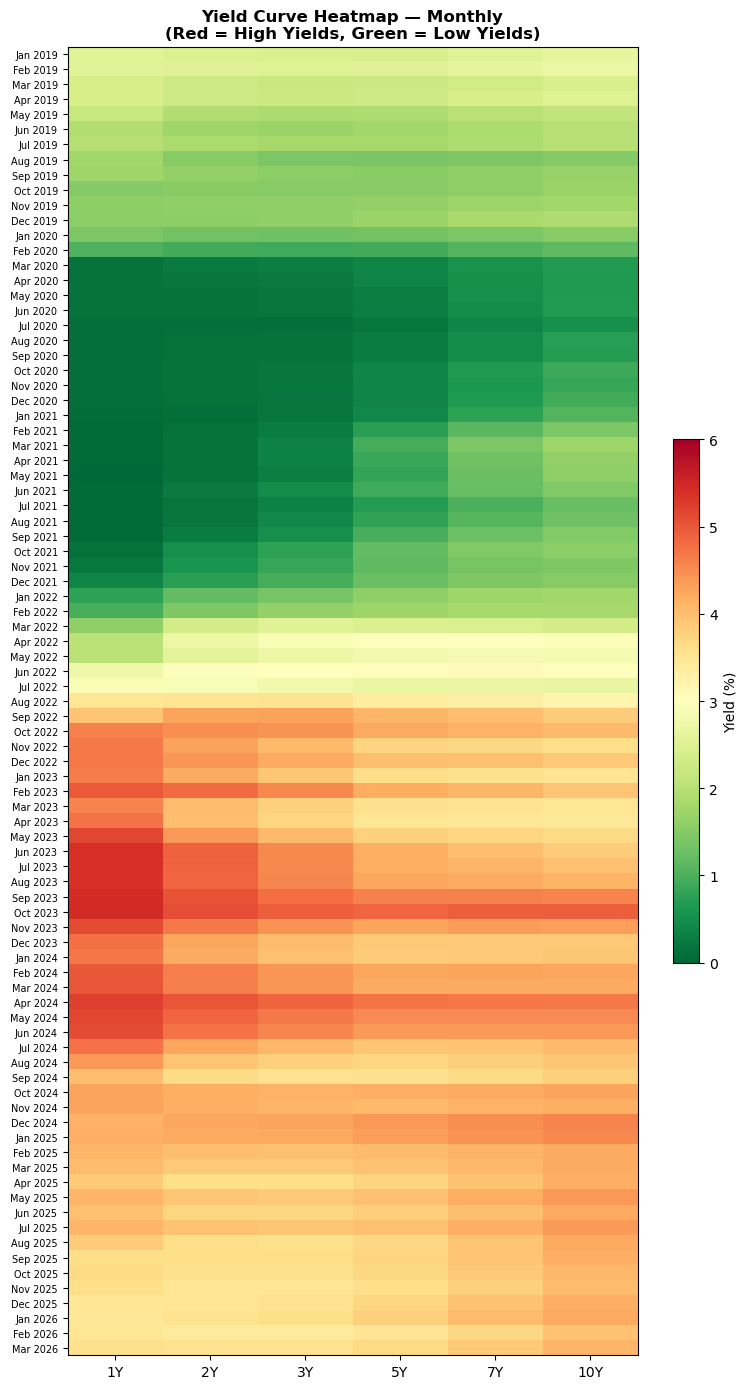

Saved: yield_curve_heatmap.png


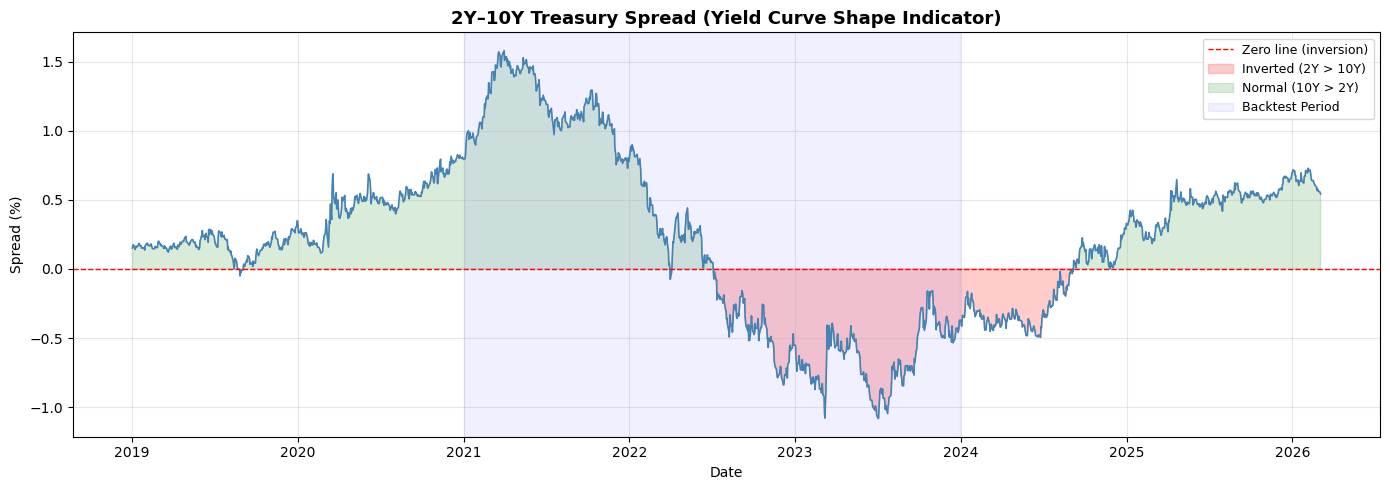

Saved: yield_curve_inversion.png

  YIELD SUMMARY STATISTICS (full period, in %)
             1Y        2Y        3Y        5Y        7Y       10Y
count  1871.000  1871.000  1871.000  1871.000  1871.000  1871.000
mean      2.716     2.652     2.626     2.663     2.779     2.870
std       1.921     1.740     1.624     1.480     1.398     1.342
min       0.033     0.104     0.113     0.191     0.359     0.508
25%       0.315     0.686     0.962     1.243     1.444     1.606
50%       3.151     3.208     3.225     3.154     3.144     3.048
75%       4.440     4.222     4.063     3.981     4.050     4.157
max       5.489     5.224     5.051     4.957     5.012     4.991

  Yield curve on most recent date:
    1Y: 3.569%
    2Y: 3.542%
    3Y: 3.549%
    5Y: 3.672%
    7Y: 3.867%
    10Y: 4.085%

  Yield curve on start of backtest (Jan 2021):
    1Y: 0.104%
    2Y: 0.122%
    3Y: 0.166%
    5Y: 0.362%
    7Y: 0.646%
    10Y: 0.916%

  Yield curve at peak rates (approx Oct 2023):
    1Y: 5.4

In [4]:
"""
Yield Curve Visualizer
-----------------------
Run AFTER yield_curve.py has created yield_curve_clean.csv
Shows how the yield curve changes over time.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

# ── Path ───────────────────────────────────────────────────────────────────
BASE_DIR   = r"C:\Users\sarda\Desktop\convertible_arb"
CLEAN_DIR  = os.path.join(BASE_DIR, "data", "clean")
CHART_DIR  = os.path.join(BASE_DIR, "output", "charts")
os.makedirs(CHART_DIR, exist_ok=True)

YIELD_FILE = os.path.join(CLEAN_DIR, "yield_curve_clean.csv")

TENORS      = [1, 2, 3, 5, 7, 10]
YIELD_COLS  = [f"yield_{t}y" for t in TENORS]
TENOR_NAMES = ["1Y", "2Y", "3Y", "5Y", "7Y", "10Y"]

# ── Load ───────────────────────────────────────────────────────────────────
df = pd.read_csv(YIELD_FILE)
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
df = df.sort_values("Date").reset_index(drop=True)

print(f"Loaded {len(df)} rows | {df['Date'].min().date()} to {df['Date'].max().date()}")

# Convert to % for display
for col in YIELD_COLS:
    df[col] = df[col] * 100

# ── Helper: plot one curve ─────────────────────────────────────────────────
def plot_single_curve(ax, row, color, label, linewidth=2, marker="o"):
    yields = [row[col] for col in YIELD_COLS]
    ax.plot(TENORS, yields, color=color, linewidth=linewidth,
            marker=marker, markersize=6, label=label)
    ax.set_xticks(TENORS)
    ax.set_xticklabels(TENOR_NAMES)
    ax.set_xlabel("Maturity")
    ax.set_ylabel("Yield (%)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)


# ══════════════════════════════════════════════════════════════════════════
# CHART 1 — Yield Curve on Key Dates
# Shows the curve shape at 6 important moments in your backtest period
# ══════════════════════════════════════════════════════════════════════════
key_dates = [
    "2019-01-02",   # Start of data
    "2020-03-20",   # COVID crash
    "2021-01-04",   # Post-COVID low rate environment
    "2022-06-15",   # Peak rate hiking cycle
    "2023-01-03",   # Rate plateau
    "2024-01-02",   # Recent
]

colors = ["steelblue", "red", "green", "darkorange", "purple", "black"]

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title("US Treasury Yield Curve — Key Dates", fontsize=14, fontweight="bold")

for date_str, color in zip(key_dates, colors):
    target = pd.to_datetime(date_str)
    # Find nearest available date
    idx = (df["Date"] - target).abs().idxmin()
    row = df.iloc[idx]
    actual_date = row["Date"].strftime("%d %b %Y")
    plot_single_curve(ax, row, color=color, label=actual_date)

plt.tight_layout()
path1 = os.path.join(CHART_DIR, "yield_curve_key_dates.png")
plt.savefig(path1, dpi=150)
plt.show()
print(f"Saved: yield_curve_key_dates.png")


# ══════════════════════════════════════════════════════════════════════════
# CHART 2 — Individual Tenor Over Time
# Shows how each yield (1Y, 2Y, etc.) evolved across the full period
# This is where you see the rate hiking cycle clearly
# ══════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 6))
ax.set_title("US Treasury Yields Over Time — All Tenors", fontsize=14, fontweight="bold")

tenor_colors = ["#e41a1c", "#ff7f00", "#4daf4a", "#377eb8", "#984ea3", "#a65628"]

for col, name, color in zip(YIELD_COLS, TENOR_NAMES, tenor_colors):
    ax.plot(df["Date"], df[col], label=name, color=color, linewidth=1.2)

# Shade the backtest period
backtest_start = pd.to_datetime("2021-01-01")
backtest_end   = pd.to_datetime("2023-12-31")
ax.axvspan(backtest_start, backtest_end, alpha=0.08, color="blue", label="Backtest Period")

ax.set_xlabel("Date")
ax.set_ylabel("Yield (%)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.tight_layout()
path2 = os.path.join(CHART_DIR, "yields_over_time.png")
plt.savefig(path2, dpi=150)
plt.show()
print(f"Saved: yields_over_time.png")


# ══════════════════════════════════════════════════════════════════════════
# CHART 3 — Yield Curve Heatmap
# One row per month, columns = tenors
# Colour intensity shows yield level — you can see the hiking cycle visually
# ══════════════════════════════════════════════════════════════════════════
# Resample to monthly (last business day of each month)
monthly = df.set_index("Date")[YIELD_COLS].resample("ME").last()
monthly.index = monthly.index.strftime("%b %Y")

fig, ax = plt.subplots(figsize=(8, 14))
im = ax.imshow(monthly.values, aspect="auto", cmap="RdYlGn_r", vmin=0, vmax=6)

ax.set_xticks(range(len(TENOR_NAMES)))
ax.set_xticklabels(TENOR_NAMES, fontsize=10)
ax.set_yticks(range(len(monthly)))
ax.set_yticklabels(monthly.index, fontsize=7)
ax.set_title("Yield Curve Heatmap — Monthly\n(Red = High Yields, Green = Low Yields)",
             fontsize=12, fontweight="bold")

plt.colorbar(im, ax=ax, label="Yield (%)", shrink=0.4)
plt.tight_layout()
path3 = os.path.join(CHART_DIR, "yield_curve_heatmap.png")
plt.savefig(path3, dpi=150)
plt.show()
print(f"Saved: yield_curve_heatmap.png")


# ══════════════════════════════════════════════════════════════════════════
# CHART 4 — 2Y vs 10Y Spread (Yield Curve Inversion Indicator)
# When this goes negative = inverted curve = important context for backtest
# ══════════════════════════════════════════════════════════════════════════
df["spread_2y_10y"] = df["yield_10y"] - df["yield_2y"]

fig, ax = plt.subplots(figsize=(14, 5))
ax.set_title("2Y–10Y Treasury Spread (Yield Curve Shape Indicator)",
             fontsize=13, fontweight="bold")

ax.plot(df["Date"], df["spread_2y_10y"], color="steelblue", linewidth=1.2)
ax.axhline(0, color="red", linewidth=1, linestyle="--", label="Zero line (inversion)")
ax.fill_between(df["Date"], df["spread_2y_10y"], 0,
                where=(df["spread_2y_10y"] < 0), color="red", alpha=0.2,
                label="Inverted (2Y > 10Y)")
ax.fill_between(df["Date"], df["spread_2y_10y"], 0,
                where=(df["spread_2y_10y"] >= 0), color="green", alpha=0.15,
                label="Normal (10Y > 2Y)")

ax.axvspan(backtest_start, backtest_end, alpha=0.06, color="blue", label="Backtest Period")

ax.set_xlabel("Date")
ax.set_ylabel("Spread (%)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.tight_layout()
path4 = os.path.join(CHART_DIR, "yield_curve_inversion.png")
plt.savefig(path4, dpi=150)
plt.show()
print(f"Saved: yield_curve_inversion.png")


# ══════════════════════════════════════════════════════════════════════════
# PRINT SUMMARY STATISTICS
# ══════════════════════════════════════════════════════════════════════════
print("\n" + "="*55)
print("  YIELD SUMMARY STATISTICS (full period, in %)")
print("="*55)
summary = df[YIELD_COLS].describe().round(3)
summary.columns = TENOR_NAMES
print(summary)

print("\n  Yield curve on most recent date:")
latest = df.iloc[-1]
for col, name in zip(YIELD_COLS, TENOR_NAMES):
    print(f"    {name}: {latest[col]:.3f}%")

print("\n  Yield curve on start of backtest (Jan 2021):")
bt_start_row = df[df["Date"] >= backtest_start].iloc[0]
for col, name in zip(YIELD_COLS, TENOR_NAMES):
    print(f"    {name}: {bt_start_row[col]:.3f}%")

print("\n  Yield curve at peak rates (approx Oct 2023):")
peak_date = pd.to_datetime("2023-10-01")
idx = (df["Date"] - peak_date).abs().idxmin()
peak_row = df.iloc[idx]
for col, name in zip(YIELD_COLS, TENOR_NAMES):
    print(f"    {name}: {peak_row[col]:.3f}%")
print("\nAll charts saved to output/charts/")
print("="*55)

Loaded 1871 rows | 2019-01-02 to 2026-03-04


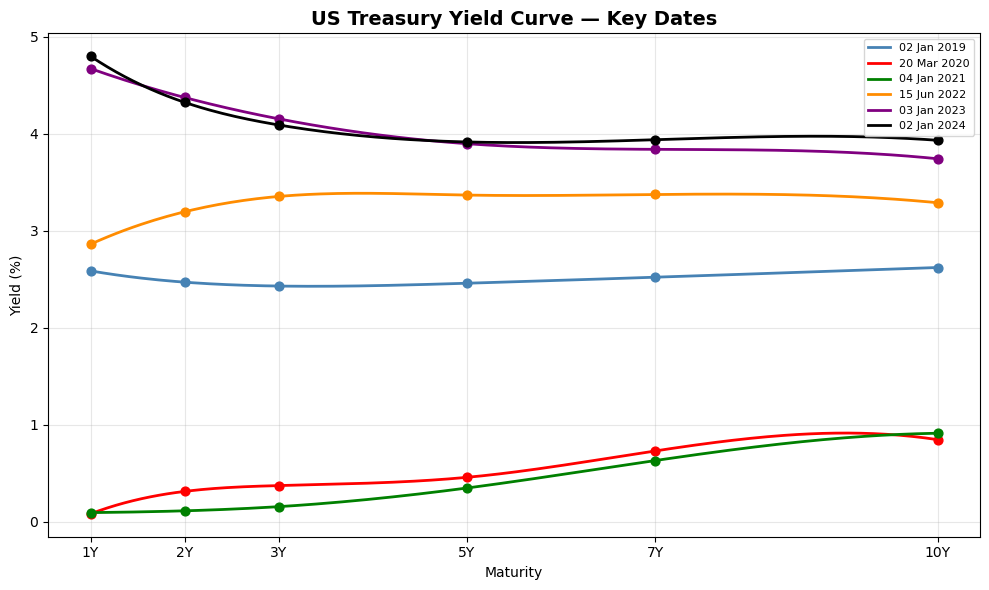

Saved: yield_curve_key_dates.png


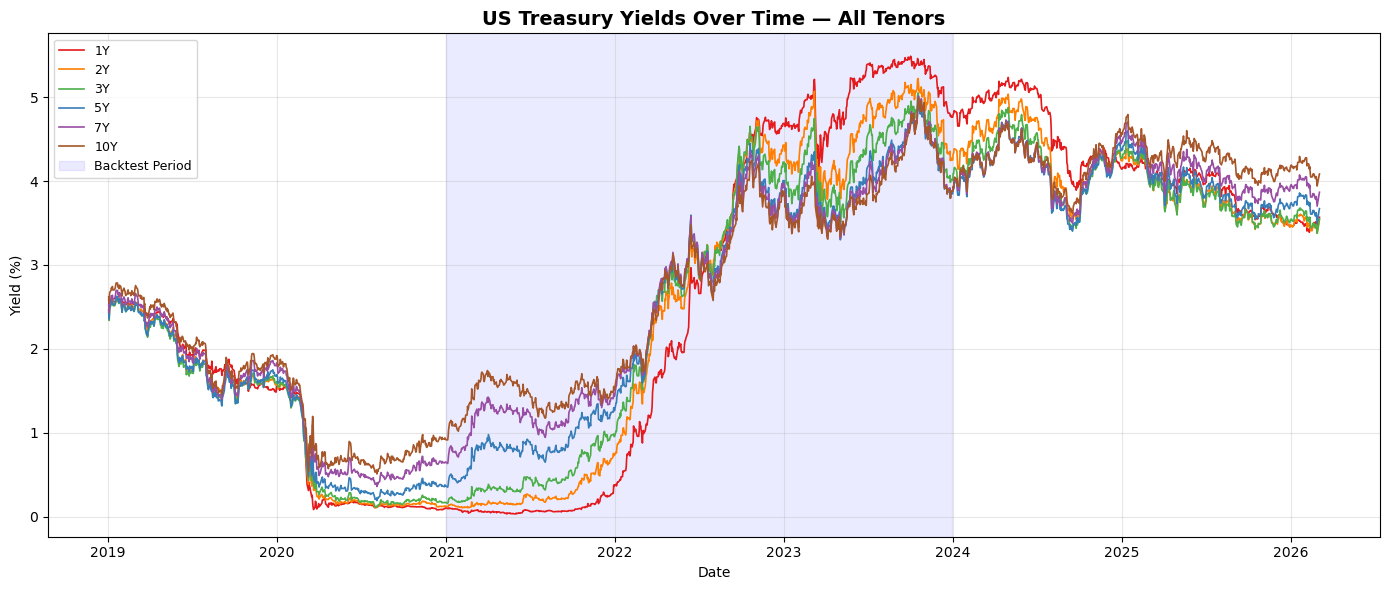

Saved: yields_over_time.png


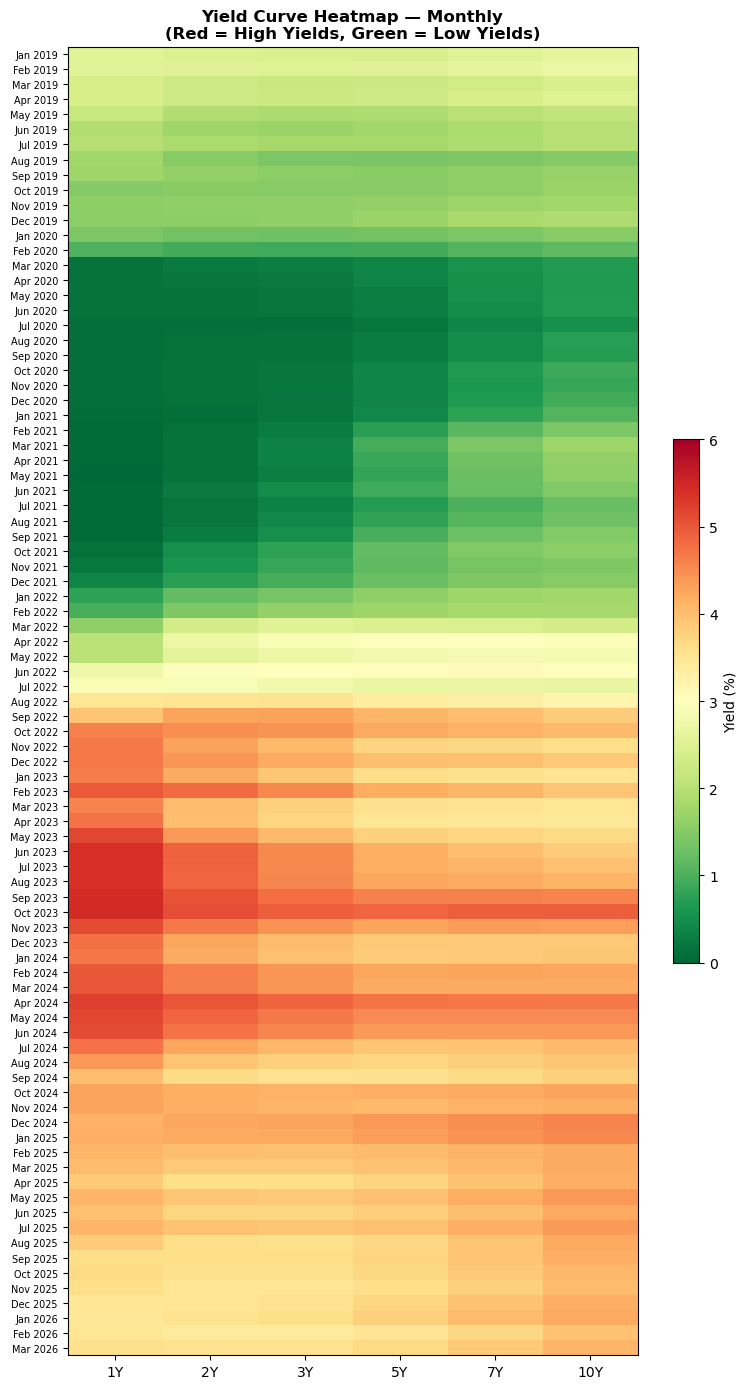

Saved: yield_curve_heatmap.png


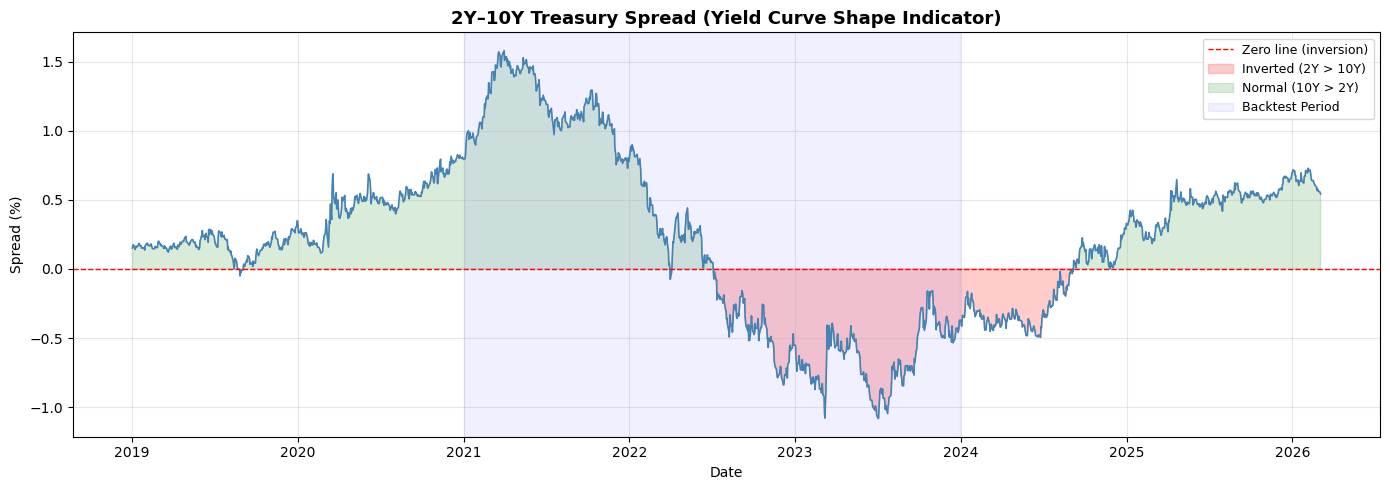

Saved: yield_curve_inversion.png

  YIELD SUMMARY STATISTICS (full period, in %)
             1Y        2Y        3Y        5Y        7Y       10Y
count  1871.000  1871.000  1871.000  1871.000  1871.000  1871.000
mean      2.716     2.652     2.626     2.663     2.779     2.870
std       1.921     1.740     1.624     1.480     1.398     1.342
min       0.033     0.104     0.113     0.191     0.359     0.508
25%       0.315     0.686     0.962     1.243     1.444     1.606
50%       3.151     3.208     3.225     3.154     3.144     3.048
75%       4.440     4.222     4.063     3.981     4.050     4.157
max       5.489     5.224     5.051     4.957     5.012     4.991

  Yield curve on most recent date:
    1Y: 3.569%
    2Y: 3.542%
    3Y: 3.549%
    5Y: 3.672%
    7Y: 3.867%
    10Y: 4.085%

  Yield curve on start of backtest (Jan 2021):
    1Y: 0.104%
    2Y: 0.122%
    3Y: 0.166%
    5Y: 0.362%
    7Y: 0.646%
    10Y: 0.916%

  Yield curve at peak rates (approx Oct 2023):
    1Y: 5.4

In [5]:
"""
Yield Curve Visualizer
-----------------------
Run AFTER yield_curve.py has created yield_curve_clean.csv
Shows how the yield curve changes over time.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
from scipy.interpolate import CubicSpline
# ── Path ───────────────────────────────────────────────────────────────────
BASE_DIR   = r"C:\Users\sarda\Desktop\convertible_arb"
CLEAN_DIR  = os.path.join(BASE_DIR, "data", "clean")
CHART_DIR  = os.path.join(BASE_DIR, "output", "charts")
os.makedirs(CHART_DIR, exist_ok=True)

YIELD_FILE = os.path.join(CLEAN_DIR, "yield_curve_clean.csv")

TENORS      = [1, 2, 3, 5, 7, 10]
YIELD_COLS  = [f"yield_{t}y" for t in TENORS]
TENOR_NAMES = ["1Y", "2Y", "3Y", "5Y", "7Y", "10Y"]

# ── Load ───────────────────────────────────────────────────────────────────
df = pd.read_csv(YIELD_FILE)
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
df = df.sort_values("Date").reset_index(drop=True)

print(f"Loaded {len(df)} rows | {df['Date'].min().date()} to {df['Date'].max().date()}")

# Convert to % for display
for col in YIELD_COLS:
    df[col] = df[col] * 100

# ── Helper: plot one curve ─────────────────────────────────────────────────


def plot_single_curve(ax, row, color, label, linewidth=2, marker="o"):
    yields = [row[col] for col in YIELD_COLS]
    
    # Fit a smooth spline through the 6 real points
    cs = CubicSpline(TENORS, yields)
    
    # Generate 200 smooth points between 1Y and 10Y
    smooth_x = np.linspace(TENORS[0], TENORS[-1], 200)
    smooth_y = cs(smooth_x)
    
    # Draw smooth curve
    ax.plot(smooth_x, smooth_y, color=color, linewidth=linewidth, label=label)
    
    # Plot the actual data points on top
    ax.scatter(TENORS, yields, color=color, s=40, zorder=5)
    
    ax.set_xticks(TENORS)
    ax.set_xticklabels(TENOR_NAMES)
    ax.set_xlabel("Maturity")
    ax.set_ylabel("Yield (%)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)


# ══════════════════════════════════════════════════════════════════════════
# CHART 1 — Yield Curve on Key Dates
# Shows the curve shape at 6 important moments in your backtest period
# ══════════════════════════════════════════════════════════════════════════
key_dates = [
    "2019-01-02",   # Start of data
    "2020-03-20",   # COVID crash
    "2021-01-04",   # Post-COVID low rate environment
    "2022-06-15",   # Peak rate hiking cycle
    "2023-01-03",   # Rate plateau
    "2024-01-02",   # Recent
]

colors = ["steelblue", "red", "green", "darkorange", "purple", "black"]

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title("US Treasury Yield Curve — Key Dates", fontsize=14, fontweight="bold")

for date_str, color in zip(key_dates, colors):
    target = pd.to_datetime(date_str)
    # Find nearest available date
    idx = (df["Date"] - target).abs().idxmin()
    row = df.iloc[idx]
    actual_date = row["Date"].strftime("%d %b %Y")
    plot_single_curve(ax, row, color=color, label=actual_date)

plt.tight_layout()
path1 = os.path.join(CHART_DIR, "yield_curve_key_dates.png")
plt.savefig(path1, dpi=150)
plt.show()
print(f"Saved: yield_curve_key_dates.png")


# ══════════════════════════════════════════════════════════════════════════
# CHART 2 — Individual Tenor Over Time
# Shows how each yield (1Y, 2Y, etc.) evolved across the full period
# This is where you see the rate hiking cycle clearly
# ══════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 6))
ax.set_title("US Treasury Yields Over Time — All Tenors", fontsize=14, fontweight="bold")

tenor_colors = ["#e41a1c", "#ff7f00", "#4daf4a", "#377eb8", "#984ea3", "#a65628"]

for col, name, color in zip(YIELD_COLS, TENOR_NAMES, tenor_colors):
    ax.plot(df["Date"], df[col], label=name, color=color, linewidth=1.2)

# Shade the backtest period
backtest_start = pd.to_datetime("2021-01-01")
backtest_end   = pd.to_datetime("2023-12-31")
ax.axvspan(backtest_start, backtest_end, alpha=0.08, color="blue", label="Backtest Period")

ax.set_xlabel("Date")
ax.set_ylabel("Yield (%)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.tight_layout()
path2 = os.path.join(CHART_DIR, "yields_over_time.png")
plt.savefig(path2, dpi=150)
plt.show()
print(f"Saved: yields_over_time.png")


# ══════════════════════════════════════════════════════════════════════════
# CHART 3 — Yield Curve Heatmap
# One row per month, columns = tenors
# Colour intensity shows yield level — you can see the hiking cycle visually
# ══════════════════════════════════════════════════════════════════════════
# Resample to monthly (last business day of each month)
monthly = df.set_index("Date")[YIELD_COLS].resample("ME").last()
monthly.index = monthly.index.strftime("%b %Y")

fig, ax = plt.subplots(figsize=(8, 14))
im = ax.imshow(monthly.values, aspect="auto", cmap="RdYlGn_r", vmin=0, vmax=6)

ax.set_xticks(range(len(TENOR_NAMES)))
ax.set_xticklabels(TENOR_NAMES, fontsize=10)
ax.set_yticks(range(len(monthly)))
ax.set_yticklabels(monthly.index, fontsize=7)
ax.set_title("Yield Curve Heatmap — Monthly\n(Red = High Yields, Green = Low Yields)",
             fontsize=12, fontweight="bold")

plt.colorbar(im, ax=ax, label="Yield (%)", shrink=0.4)
plt.tight_layout()
path3 = os.path.join(CHART_DIR, "yield_curve_heatmap.png")
plt.savefig(path3, dpi=150)
plt.show()
print(f"Saved: yield_curve_heatmap.png")


# ══════════════════════════════════════════════════════════════════════════
# CHART 4 — 2Y vs 10Y Spread (Yield Curve Inversion Indicator)
# When this goes negative = inverted curve = important context for backtest
# ══════════════════════════════════════════════════════════════════════════
df["spread_2y_10y"] = df["yield_10y"] - df["yield_2y"]

fig, ax = plt.subplots(figsize=(14, 5))
ax.set_title("2Y–10Y Treasury Spread (Yield Curve Shape Indicator)",
             fontsize=13, fontweight="bold")

ax.plot(df["Date"], df["spread_2y_10y"], color="steelblue", linewidth=1.2)
ax.axhline(0, color="red", linewidth=1, linestyle="--", label="Zero line (inversion)")
ax.fill_between(df["Date"], df["spread_2y_10y"], 0,
                where=(df["spread_2y_10y"] < 0), color="red", alpha=0.2,
                label="Inverted (2Y > 10Y)")
ax.fill_between(df["Date"], df["spread_2y_10y"], 0,
                where=(df["spread_2y_10y"] >= 0), color="green", alpha=0.15,
                label="Normal (10Y > 2Y)")

ax.axvspan(backtest_start, backtest_end, alpha=0.06, color="blue", label="Backtest Period")

ax.set_xlabel("Date")
ax.set_ylabel("Spread (%)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.tight_layout()
path4 = os.path.join(CHART_DIR, "yield_curve_inversion.png")
plt.savefig(path4, dpi=150)
plt.show()
print(f"Saved: yield_curve_inversion.png")


# ══════════════════════════════════════════════════════════════════════════
# PRINT SUMMARY STATISTICS
# ══════════════════════════════════════════════════════════════════════════
print("\n" + "="*55)
print("  YIELD SUMMARY STATISTICS (full period, in %)")
print("="*55)
summary = df[YIELD_COLS].describe().round(3)
summary.columns = TENOR_NAMES
print(summary)

print("\n  Yield curve on most recent date:")
latest = df.iloc[-1]
for col, name in zip(YIELD_COLS, TENOR_NAMES):
    print(f"    {name}: {latest[col]:.3f}%")

print("\n  Yield curve on start of backtest (Jan 2021):")
bt_start_row = df[df["Date"] >= backtest_start].iloc[0]
for col, name in zip(YIELD_COLS, TENOR_NAMES):
    print(f"    {name}: {bt_start_row[col]:.3f}%")

print("\n  Yield curve at peak rates (approx Oct 2023):")
peak_date = pd.to_datetime("2023-10-01")
idx = (df["Date"] - peak_date).abs().idxmin()
peak_row = df.iloc[idx]
for col, name in zip(YIELD_COLS, TENOR_NAMES):
    print(f"    {name}: {peak_row[col]:.3f}%")
print("\nAll charts saved to output/charts/")
print("="*55)

In [6]:
"""
Yield Curve Loader, Cleaner, and Discount Rate Builder
--------------------------------------------------------
Loads GT1–GT10 Bloomberg exports + BBB credit spread (LUACOAS),
combines into a single daily yield curve table,
interpolates to any maturity, builds final discount rate table,
and saves both to the clean folder.
"""

import pandas as pd
import numpy as np
import os

# ── Paths ──────────────────────────────────────────────────────────────────
BASE_DIR    = r"C:\Users\sarda\Desktop\convertible_arb"
YIELD_DIR   = os.path.join(BASE_DIR, "data", "raw", "yields")
SPREAD_DIR  = os.path.join(BASE_DIR, "data", "raw", "spreads")
CLEAN_DIR   = os.path.join(BASE_DIR, "data", "clean")
os.makedirs(CLEAN_DIR, exist_ok=True)

# ── Tenor map: filename → years ────────────────────────────────────────────
TENOR_MAP = {
    "GT1":  1,
    "GT2":  2,
    "GT3":  3,
    "GT5":  5,
    "GT7":  7,
    "GT10": 10,
}

TENORS     = [1, 2, 3, 5, 7, 10]
YIELD_COLS = [f"yield_{t}y" for t in TENORS]


# ══════════════════════════════════════════════════════════════════════════
# SECTION 1 — YIELD CURVE
# ══════════════════════════════════════════════════════════════════════════

def load_single_tenor(filename, tenor_years):
    """
    Load one Bloomberg GT xlsx file.
    Metadata in rows 1-5, header on row 6, data from row 7.
    Dates in dd-mm-yyyy format. We use PX_LAST as the yield.
    """
    filepath = os.path.join(YIELD_DIR, f"{filename}.xlsx")

    df = pd.read_excel(
        filepath,
        header=5,
        usecols=[0, 1],
        parse_dates=False
    )

    df.columns = ["Date", f"yield_{tenor_years}y"]
    df = df.dropna(subset=["Date"])
    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
    df = df.dropna(subset=["Date"])
    df[f"yield_{tenor_years}y"] = pd.to_numeric(
        df[f"yield_{tenor_years}y"], errors="coerce"
    )
    df = df.sort_values("Date").reset_index(drop=True)

    print(f"  Loaded {filename}: {len(df)} rows | "
          f"{df['Date'].min().date()} to {df['Date'].max().date()} | "
          f"Missing: {df[f'yield_{tenor_years}y'].isna().sum()}")

    return df


def build_yield_curve():
    print("\n[1] Loading yield curve files...")
    merged = None
    for filename, tenor_years in TENOR_MAP.items():
        df = load_single_tenor(filename, tenor_years)
        merged = df if merged is None else pd.merge(
            merged, df, on="Date", how="outer"
        )
    merged = merged.sort_values("Date").reset_index(drop=True)
    print(f"\n  Combined shape: {merged.shape}")
    return merged


def clean_yield_curve(df):
    print("\n[2] Cleaning yield curve...")

    # Keep weekdays only
    df = df[df["Date"].dt.dayofweek < 5].copy()

    # Reindex to full weekday calendar
    full_index = pd.bdate_range(
        start=df["Date"].min(), end=df["Date"].max()
    )
    df = df.set_index("Date").reindex(full_index)
    df.index.name = "Date"

    missing_before = df.isna().sum()
    df = df.ffill().bfill()
    missing_after  = df.isna().sum()

    print(f"  Missing before fill:\n{missing_before}")
    print(f"  Missing after fill: \n{missing_after}")

    # Convert % → decimal (4.085 → 0.04085)
    df[YIELD_COLS] = df[YIELD_COLS] / 100

    df = df.reset_index()
    print(f"\n  Final yield curve shape: {df.shape}")
    return df


def save_yield_curve(df):
    path = os.path.join(CLEAN_DIR, "yield_curve_clean.csv")
    df.to_csv(path, index=False)
    print(f"\n[3] Saved yield_curve_clean.csv → {path}")
    return path


# ══════════════════════════════════════════════════════════════════════════
# SECTION 2 — BBB CREDIT SPREAD (LUACOAS)
# ══════════════════════════════════════════════════════════════════════════

def load_bbb_spread():
    """
    Load the BBB credit spread file (LUACOAS / spread_bbb.xlsx).
    Structure:
        Rows 1-6 = Bloomberg metadata
        Row 7    = header (Date | PX_LAST | PX_BID)
        Row 8+   = data, newest first, dates in dd-mm-yyyy
    Values are already in % (e.g. 0.83 means 0.83%)
    We divide by 100 to convert to decimal.
    """
    print("\n[4] Loading BBB credit spread (LUACOAS)...")

    # Try both likely filenames
    for fname in ["spread_bbb.xlsx", "LUACOAS.xlsx", "BBB_INDEX.xlsx"]:
        fpath = os.path.join(SPREAD_DIR, fname)
        if os.path.exists(fpath):
            filepath = fpath
            print(f"  Found: {fname}")
            break
    else:
        raise FileNotFoundError(
            f"Could not find BBB spread file in {SPREAD_DIR}. "
            "Expected: spread_bbb.xlsx or LUACOAS.xlsx"
        )

    df = pd.read_excel(
        filepath,
        header=6,          # row index 6 = row 7 in Excel = our real header
        usecols=[0, 1],    # Date and PX_LAST only
        parse_dates=False
    )

    df.columns = ["Date", "spread_bbb"]
    df = df.dropna(subset=["Date"])
    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
    df = df.dropna(subset=["Date"])
    df["spread_bbb"] = pd.to_numeric(df["spread_bbb"], errors="coerce")

    # Sort oldest to newest
    df = df.sort_values("Date").reset_index(drop=True)

    # Convert % → decimal
    df["spread_bbb"] = df["spread_bbb"] / 100

    print(f"  Rows: {len(df)} | "
          f"{df['Date'].min().date()} to {df['Date'].max().date()}")
    print(f"  Spread range: "
          f"{df['spread_bbb'].min()*100:.3f}% "
          f"to {df['spread_bbb'].max()*100:.3f}%")
    print(f"  Missing: {df['spread_bbb'].isna().sum()}")

    # Sanity check — BBB spreads should be between 0.3% and 6%
    suspicious = df[
        (df["spread_bbb"] < 0.003) | (df["spread_bbb"] > 0.06)
    ]
    if len(suspicious) > 0:
        print(f"\n  WARNING: {len(suspicious)} rows with unusual spread values")
        print(f"  Sample:\n{suspicious.head()}")
        print("  Expected range: 0.3% to 6.0% — check if values are in bps not %")
    else:
        print("  Sanity check passed — all spread values in expected range")

    return df


# ══════════════════════════════════════════════════════════════════════════
# SECTION 3 — BUILD DISCOUNT RATE TABLE
# ══════════════════════════════════════════════════════════════════════════

def build_discount_rate_table(yield_curve_df, spread_df):
    """
    For each date, for each tenor:
        Discount Rate = Treasury Yield + BBB Credit Spread

    Output columns:
        Date
        yield_1y  ... yield_10y        (raw Treasury yields, decimal)
        spread_bbb                      (BBB spread, decimal)
        discount_1y ... discount_10y   (yield + spread for each tenor)
    """
    print("\n[5] Building discount rate table...")

    # Merge yield curve with spread on Date
    merged = pd.merge(
        yield_curve_df,
        spread_df[["Date", "spread_bbb"]],
        on="Date",
        how="left"          # keep all yield curve dates
    )

    # Forward fill any missing spread days (holidays etc.)
    missing_spread = merged["spread_bbb"].isna().sum()
    if missing_spread > 0:
        print(f"  Forward filling {missing_spread} missing spread dates...")
        merged["spread_bbb"] = merged["spread_bbb"].ffill().bfill()

    # Build discount rate columns for each tenor
    # Discount Rate = Treasury Yield (tenor-matched) + BBB Spread
    discount_cols = []
    for t in TENORS:
        col_name = f"discount_{t}y"
        merged[col_name] = merged[f"yield_{t}y"] + merged["spread_bbb"]
        discount_cols.append(col_name)

    # Print a sample to verify
    print(f"\n  Shape: {merged.shape}")
    print(f"\n  Sample row (most recent date):")

    latest = merged.iloc[-1]
    print(f"    Date:        {latest['Date'].date()}")
    print(f"    BBB Spread:  {latest['spread_bbb']*100:.3f}%")
    print(f"\n    {'Tenor':<8} {'Treasury':>10} {'+ Spread':>10} {'= Discount':>12}")
    print(f"    {'-'*44}")
    for t in TENORS:
        treasury = latest[f"yield_{t}y"] * 100
        discount = latest[f"discount_{t}y"] * 100
        spread   = latest["spread_bbb"] * 100
        print(f"    {str(t)+'Y':<8} {treasury:>9.3f}% {spread:>9.3f}%"
              f" {discount:>11.3f}%")

    return merged


def save_discount_rate_table(df):
    path = os.path.join(CLEAN_DIR, "final_discount_rates_daily.csv")
    df.to_csv(path, index=False)
    print(f"\n[6] Saved final_discount_rates_daily.csv → {path}")
    return path


# ══════════════════════════════════════════════════════════════════════════
# SECTION 4 — INTERPOLATION FUNCTION
# (used later in bond_floor.py for exact maturity matching)
# ══════════════════════════════════════════════════════════════════════════

def interpolate_discount_rate(df_discount, date, maturity_years):
    """
    Given a date and remaining bond maturity in years,
    returns the interpolated discount rate (Treasury + BBB spread).

    Parameters:
        df_discount    : final_discount_rates_daily dataframe
        date           : the date you want the rate for
        maturity_years : remaining maturity of the bond (float, e.g. 2.3)

    Returns:
        discount rate as decimal (e.g. 0.0677 for 6.77%)
    """
    date = pd.to_datetime(date)
    row  = df_discount[df_discount["Date"] == date]

    # If exact date not found, use nearest available
    if row.empty:
        idx = (df_discount["Date"] - date).abs().idxmin()
        row = df_discount.iloc[[idx]]

    discount_rates = {t: row[f"discount_{t}y"].values[0] for t in TENORS}

    # Clamp to curve boundaries
    if maturity_years <= TENORS[0]:
        return discount_rates[TENORS[0]]
    if maturity_years >= TENORS[-1]:
        return discount_rates[TENORS[-1]]

    # Find surrounding tenors and interpolate
    lower = max(t for t in TENORS if t <= maturity_years)
    upper = min(t for t in TENORS if t >= maturity_years)

    if lower == upper:
        return discount_rates[lower]

    rate = discount_rates[lower] + (
        (maturity_years - lower) / (upper - lower)
    ) * (discount_rates[upper] - discount_rates[lower])

    return rate


# ══════════════════════════════════════════════════════════════════════════
# SECTION 5 — SANITY CHECKS
# ══════════════════════════════════════════════════════════════════════════

def sanity_check(df):
    print("\n[7] Sanity checks on discount rates...")

    discount_cols = [f"discount_{t}y" for t in TENORS]
    tenor_names   = ["1Y", "2Y", "3Y", "5Y", "7Y", "10Y"]

    for col, name in zip(discount_cols, tenor_names):
        min_r = df[col].min() * 100
        max_r = df[col].max() * 100
        print(f"  {name}: min={min_r:.3f}%  max={max_r:.3f}%")
        if min_r < 0:
            print(f"    WARNING: Negative discount rates in {name}")
        if max_r > 12:
            print(f"    WARNING: Discount rates above 12% in {name}")

    # Test the interpolation function
    test_date     = df["Date"].iloc[len(df) // 2]
    test_maturity = 2.3
    test_rate     = interpolate_discount_rate(df, test_date, test_maturity)
    print(f"\n  Interpolation test:")
    print(f"    Date={test_date.date()}, Maturity={test_maturity}y "
          f"→ Discount Rate={test_rate*100:.3f}%")

    # COVID spike check — spreads should have been wide in March 2020
    covid_date = pd.to_datetime("2020-03-20")
    idx        = (df["Date"] - covid_date).abs().idxmin()
    covid_row  = df.iloc[idx]
    print(f"\n  COVID stress check ({covid_row['Date'].date()}):")
    print(f"    BBB Spread:       {covid_row['spread_bbb']*100:.3f}%")
    print(f"    2Y Discount Rate: {covid_row['discount_2y']*100:.3f}%")
    print(f"    5Y Discount Rate: {covid_row['discount_5y']*100:.3f}%")


# ══════════════════════════════════════════════════════════════════════════
# MAIN
# ══════════════════════════════════════════════════════════════════════════

if __name__ == "__main__":
    print("=" * 60)
    print("  YIELD CURVE + DISCOUNT RATE PIPELINE")
    print("=" * 60)

    # Step 1-3: Build and save yield curve
    raw_yields    = build_yield_curve()
    clean_yields  = clean_yield_curve(raw_yields)
    save_yield_curve(clean_yields)

    # Step 4: Load BBB spread
    bbb_spread    = load_bbb_spread()

    # Step 5-6: Build and save discount rate table
    discount_df   = build_discount_rate_table(clean_yields, bbb_spread)
    sanity_check(discount_df)
    save_discount_rate_table(discount_df)

    print("\n" + "=" * 60)
    print("  OUTPUT FILES:")
    print(f"  → data/clean/yield_curve_clean.csv")
    print(f"  → data/clean/final_discount_rates_daily.csv")
    print("=" * 60)
    print("\nDone. Ready for bond floor calculation.")

  YIELD CURVE + DISCOUNT RATE PIPELINE

[1] Loading yield curve files...
  Loaded GT1: 1871 rows | 2019-01-02 to 2026-03-04 | Missing: 0
  Loaded GT2: 1869 rows | 2019-01-02 to 2026-03-04 | Missing: 0
  Loaded GT3: 1869 rows | 2019-01-02 to 2026-03-04 | Missing: 0
  Loaded GT5: 1869 rows | 2019-01-02 to 2026-03-04 | Missing: 0
  Loaded GT7: 1869 rows | 2019-01-02 to 2026-03-04 | Missing: 0
  Loaded GT10: 1869 rows | 2019-01-02 to 2026-03-04 | Missing: 0

  Combined shape: (1871, 7)

[2] Cleaning yield curve...
  Missing before fill:
yield_1y     0
yield_2y     2
yield_3y     2
yield_5y     2
yield_7y     2
yield_10y    2
dtype: int64
  Missing after fill: 
yield_1y     0
yield_2y     0
yield_3y     0
yield_5y     0
yield_7y     0
yield_10y    0
dtype: int64

  Final yield curve shape: (1871, 7)

[3] Saved yield_curve_clean.csv → C:\Users\sarda\Desktop\convertible_arb\data\clean\yield_curve_clean.csv

[4] Loading BBB credit spread (LUACOAS)...
  Found: spread_bbb.xlsx
  Rows: 1815 | 201

In [1]:
"""
Yield Curve Loader, Cleaner, and Discount Rate Builder
--------------------------------------------------------
Zero coupon Treasury yields from FRED (THREEFY2/3/5/7/10)
1-year point from Bloomberg GT1 (YTM proxy — negligible difference at 1Y)
BBB credit spread from Bloomberg LUACOAS

Two rate series produced per tenor:
    risk_free_Xy  = ZC Treasury only       → binomial tree (option pricing)
    discount_Xy   = ZC Treasury + BBB spread → bond floor discounting

Per professor feedback:
    Straight bond → discounted using Treasury + issuer credit spread
    Equity option → valued using risk-free rates only (risk-neutral pricing)
"""

import pandas as pd
import numpy as np
import os

# ── Paths ──────────────────────────────────────────────────────────────────
BASE_DIR   = r"C:\Users\sarda\Desktop\convertible_arb"
YIELD_DIR  = os.path.join(BASE_DIR, "data", "raw", "yields")
SPREAD_DIR = os.path.join(BASE_DIR, "data", "raw", "spreads")
CLEAN_DIR  = os.path.join(BASE_DIR, "data", "clean")
os.makedirs(CLEAN_DIR, exist_ok=True)

# ── FRED file config (2Y to 10Y only — 1Y handled separately via GT1) ──────
# (filename, tenor_years, sheet_name, date_format, file_type)
FRED_FILES = [
    ("THREEFY2",  2,  "Daily", "standard", "xlsx"),
    ("THREEFY3",  3,  "Daily", "standard", "xlsx"),
    ("THREEFY5",  5,  "Daily", "standard", "xlsx"),
    ("THREEFY7",  7,  "Daily", "standard", "xlsx"),
    ("THREEFY10", 10, "Daily", "standard", "xlsx"),
]

TENORS     = [1, 2, 3, 5, 7, 10]
YIELD_COLS = [f"yield_{t}y" for t in TENORS]


# ══════════════════════════════════════════════════════════════════════════
# SECTION 1 — LOAD DATA
# ══════════════════════════════════════════════════════════════════════════

def load_fred_tenor(filename, tenor_years, sheet_name, date_format, file_type):
    """
    Load one FRED THREEFY xlsx file.

    All THREEFY2-10 files:
        - Two sheets: README and Daily
        - Data in Daily sheet
        - Row 1: headers (observation_date | THREEFYx)
        - Row 2+: data, dates in yyyy-mm-dd
        - Blank cells = missing values, handled via dropna + ffill
        - Values in percent (e.g. 2.53 = 2.53%)
    """
    col_name = f"yield_{tenor_years}y"

    if file_type == "csv":
        filepath = os.path.join(YIELD_DIR, f"{filename}.csv")
        df = pd.read_csv(
            filepath,
            header=0,
            usecols=[0, 1],
            parse_dates=False
        )
    else:
        filepath = os.path.join(YIELD_DIR, f"{filename}.xlsx")
        df = pd.read_excel(
            filepath,
            sheet_name=sheet_name,
            header=0,
            usecols=[0, 1],
            parse_dates=False
        )

    df.columns = ["Date", col_name]
    df = df.dropna(subset=["Date"])

    if date_format == "dayfirst":
        df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
    else:
        df["Date"] = pd.to_datetime(df["Date"], format="%Y-%m-%d", errors="coerce")

    df = df.dropna(subset=["Date"])
    df[col_name] = pd.to_numeric(df[col_name], errors="coerce")
    df = df.sort_values("Date").reset_index(drop=True)

    n_missing = df[col_name].isna().sum()
    print(f"  Loaded {filename}: {len(df)} rows | "
          f"{df['Date'].min().date()} to {df['Date'].max().date()} | "
          f"Blank yield values: {n_missing}")

    return df


def load_gt1_bloomberg():
    """
    Load Bloomberg GT1 1-year Treasury yield as the 1-year point.

    Used instead of THREEFY1 because THREEFY1 lacks daily frequency
    (only ~737 observations vs ~1868 needed). At the 1-year maturity,
    the difference between YTM and zero coupon rates is negligible
    (typically < 5 bps) so GT1 is an acceptable proxy.

    Bloomberg GT1 file structure:
        Rows 1-5 = Bloomberg metadata
        Row 6    = header: Date | PX_LAST | PX_BID
        Row 7+   = data, newest first, dates in dd-mm-yyyy
    Values in percent (e.g. 4.085 = 4.085%)
    """
    print("\n  Loading GT1 Bloomberg (1Y proxy for zero coupon)...")

    filepath = os.path.join(YIELD_DIR, "GT1.xlsx")

    if not os.path.exists(filepath):
        raise FileNotFoundError(
            f"GT1.xlsx not found in {YIELD_DIR}.\n"
            f"Please ensure the Bloomberg GT1 export is in the yields folder."
        )

    df = pd.read_excel(
        filepath,
        header=5,           # row index 5 = row 6 in Excel = real header
        usecols=[0, 1],     # Date and PX_LAST only
        parse_dates=False
    )

    df.columns = ["Date", "yield_1y"]
    df = df.dropna(subset=["Date"])
    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
    df = df.dropna(subset=["Date"])
    df["yield_1y"] = pd.to_numeric(df["yield_1y"], errors="coerce")
    df = df.sort_values("Date").reset_index(drop=True)

    n_missing = df["yield_1y"].isna().sum()
    print(f"  Loaded GT1: {len(df)} rows | "
          f"{df['Date'].min().date()} to {df['Date'].max().date()} | "
          f"Blank values: {n_missing}")

    return df


def build_yield_curve():
    """
    Load all FRED files (2Y-10Y) + Bloomberg GT1 (1Y)
    and merge into one daily dataframe.
    One row per date, one column per tenor.
    """
    print("\n[1] Loading yield curve files...")

    # Load FRED files (2Y to 10Y)
    merged = None
    for filename, tenor_years, sheet_name, date_format, file_type in FRED_FILES:
        df = load_fred_tenor(
            filename, tenor_years, sheet_name, date_format, file_type
        )
        if merged is None:
            merged = df
        else:
            merged = pd.merge(merged, df, on="Date", how="outer")

    # Load GT1 separately and merge in as the 1-year point
    gt1    = load_gt1_bloomberg()
    merged = pd.merge(merged, gt1, on="Date", how="outer")

    merged = merged.sort_values("Date").reset_index(drop=True)

    print(f"\n  Combined shape: {merged.shape}")
    print(f"  Date range: {merged['Date'].min().date()} "
          f"to {merged['Date'].max().date()}")

    return merged


# ══════════════════════════════════════════════════════════════════════════
# SECTION 2 — CLEAN
# ══════════════════════════════════════════════════════════════════════════

def clean_yield_curve(df):
    """
    1. Keep weekdays only
    2. Reindex to full business day calendar extended to today
       — fills the FRED Feb-27-2026 to today gap automatically
    3. Forward fill: handles FRED missing values, holidays, gap to today
    4. Back fill: handles any NaNs at the very start of the series
    5. Convert percent to decimal
    """
    print("\n[2] Cleaning yield curve...")

    # Keep weekdays only
    df = df[df["Date"].dt.dayofweek < 5].copy()

    # Extend to today so Feb27 gap is filled
    today      = pd.Timestamp.today().normalize()
    full_index = pd.bdate_range(start=df["Date"].min(), end=today)

    df = df.set_index("Date").reindex(full_index)
    df.index.name = "Date"

    # Reorder columns to logical order: 1y, 2y, 3y, 5y, 7y, 10y
    df = df[YIELD_COLS]

    missing_before = df.isna().sum()

    df = df.ffill()
    df = df.bfill()

    missing_after = df.isna().sum()

    print(f"  Missing values before fill:\n{missing_before}")
    print(f"  Missing values after fill: \n{missing_after}")

    # Convert percent → decimal (4.085 → 0.04085)
    df[YIELD_COLS] = df[YIELD_COLS] / 100

    df = df.reset_index()

    print(f"\n  Final shape: {df.shape}")
    print(f"  Date range: {df['Date'].min().date()} "
          f"to {df['Date'].max().date()}")

    return df


def save_yield_curve(df):
    path = os.path.join(CLEAN_DIR, "yield_curve_clean.csv")
    df.to_csv(path, index=False)
    print(f"\n[3] Saved yield_curve_clean.csv → {path}")
    return path


# ══════════════════════════════════════════════════════════════════════════
# SECTION 3 — BBB CREDIT SPREAD (LUACOAS)
# ══════════════════════════════════════════════════════════════════════════

def load_bbb_spread():
    """
    Load BBB credit spread (LUACOAS index from Bloomberg).

    Bloomberg file structure:
        Rows 1-6 = metadata
        Row 7    = header: Date | PX_LAST | PX_BID
        Row 8+   = data, newest first, dates in dd-mm-yyyy
    Values in percent (e.g. 0.83 = 0.83%).

    This spread is added ONLY to the bond floor discount rate.
    The option pricing risk-free rate does NOT include this spread.
    """
    print("\n[4] Loading BBB credit spread (LUACOAS)...")

    for fname in ["spread_bbb.xlsx", "LUACOAS.xlsx", "BBB_INDEX.xlsx"]:
        fpath = os.path.join(SPREAD_DIR, fname)
        if os.path.exists(fpath):
            filepath = fpath
            print(f"  Found: {fname}")
            break
    else:
        raise FileNotFoundError(
            f"Could not find BBB spread file in {SPREAD_DIR}.\n"
            f"Expected one of: spread_bbb.xlsx, LUACOAS.xlsx, BBB_INDEX.xlsx"
        )

    df = pd.read_excel(
        filepath,
        header=6,       # row index 6 = row 7 in Excel = real header
        usecols=[0, 1],
        parse_dates=False
    )

    df.columns = ["Date", "spread_bbb"]
    df = df.dropna(subset=["Date"])
    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
    df = df.dropna(subset=["Date"])
    df["spread_bbb"] = pd.to_numeric(df["spread_bbb"], errors="coerce")
    df = df.sort_values("Date").reset_index(drop=True)

    # Convert percent → decimal
    df["spread_bbb"] = df["spread_bbb"] / 100

    print(f"  Rows: {len(df)} | "
          f"{df['Date'].min().date()} to {df['Date'].max().date()}")
    print(f"  Spread range: {df['spread_bbb'].min()*100:.3f}% "
          f"to {df['spread_bbb'].max()*100:.3f}%")
    print(f"  Missing: {df['spread_bbb'].isna().sum()}")

    # Sanity check — BBB OAS should be 0.3% to 6%
    suspicious = df[
        (df["spread_bbb"] < 0.003) | (df["spread_bbb"] > 0.06)
    ]
    if len(suspicious) > 0:
        print(f"\n  WARNING: {len(suspicious)} rows outside expected range")
        print(f"  Sample:\n{suspicious.head()}")
        print("  Check: are values in bps instead of %? "
              "If so divide by an extra 100.")
    else:
        print("  Sanity check passed — spreads in expected range (0.3%–6%)")

    return df


# ══════════════════════════════════════════════════════════════════════════
# SECTION 4 — BUILD DISCOUNT RATE TABLE
# ══════════════════════════════════════════════════════════════════════════

def build_discount_rate_table(yield_curve_df, spread_df):
    """
    Merges zero coupon Treasury yields with BBB credit spread.

    Produces TWO rate series per tenor per professor's feedback:

        risk_free_Xy  = ZC Treasury only
                        → input to binomial tree for option pricing
                        → risk-neutral pricing uses risk-free rate only

        discount_Xy   = ZC Treasury + BBB spread
                        → input to bond floor discounting
                        → straight bond cash flows carry default risk

    Output columns:
        Date
        yield_1y ... yield_10y        raw Treasury yields (decimal)
        spread_bbb                    BBB credit spread (decimal)
        risk_free_1y ... risk_free_10y
        discount_1y  ... discount_10y
    """
    print("\n[5] Building discount rate table...")

    merged = pd.merge(
        yield_curve_df,
        spread_df[["Date", "spread_bbb"]],
        on="Date",
        how="left"
    )

    # Fill any missing spread dates
    n_missing = merged["spread_bbb"].isna().sum()
    if n_missing > 0:
        print(f"  Forward filling {n_missing} missing spread dates...")
        merged["spread_bbb"] = merged["spread_bbb"].ffill().bfill()

    # Build both rate columns for each tenor
    for t in TENORS:
        merged[f"risk_free_{t}y"] = merged[f"yield_{t}y"]
        merged[f"discount_{t}y"]  = merged[f"yield_{t}y"] + merged["spread_bbb"]

    # Print verification table
    print(f"\n  Shape: {merged.shape}")
    latest = merged.iloc[-1]
    print(f"\n  Sample — most recent date: {latest['Date'].date()}")
    print(f"  BBB Spread: {latest['spread_bbb']*100:.3f}%")
    print(f"\n  {'Tenor':<6} {'ZC Treasury':>12} {'BBB Spread':>11} "
          f"{'Bond Floor Rate':>16} {'Option Rate':>12}")
    print(f"  {'-'*60}")
    for t in TENORS:
        zc = latest[f"yield_{t}y"] * 100
        sp = latest["spread_bbb"] * 100
        dr = latest[f"discount_{t}y"] * 100
        rf = latest[f"risk_free_{t}y"] * 100
        print(f"  {str(t)+'Y':<6} {zc:>11.3f}% {sp:>10.3f}% "
              f"{dr:>15.3f}% {rf:>11.3f}%")

    return merged


def save_discount_rate_table(df):
    path = os.path.join(CLEAN_DIR, "final_discount_rates_daily.csv")
    df.to_csv(path, index=False)
    print(f"\n[6] Saved final_discount_rates_daily.csv → {path}")
    return path


# ══════════════════════════════════════════════════════════════════════════
# SECTION 5 — INTERPOLATION FUNCTIONS
# Imported and called by bond_floor.py and binomial_tree.py
# ══════════════════════════════════════════════════════════════════════════

def _get_row(df, date):
    """Return the nearest available row in df for a given date."""
    date = pd.to_datetime(date)
    row  = df[df["Date"] == date]
    if row.empty:
        idx = (df["Date"] - date).abs().idxmin()
        row = df.iloc[[idx]]
    return row


def _linear_interp(rates_dict, maturity_years):
    """Linearly interpolate between two tenor points."""
    tenors = sorted(rates_dict.keys())

    if maturity_years <= tenors[0]:
        return rates_dict[tenors[0]]
    if maturity_years >= tenors[-1]:
        return rates_dict[tenors[-1]]

    lower = max(t for t in tenors if t <= maturity_years)
    upper = min(t for t in tenors if t >= maturity_years)

    if lower == upper:
        return rates_dict[lower]

    return rates_dict[lower] + (
        (maturity_years - lower) / (upper - lower)
    ) * (rates_dict[upper] - rates_dict[lower])


def interpolate_discount_rate(df_discount, date, maturity_years):
    """
    Bond floor discount rate = ZC Treasury + BBB spread.
    Call this from bond_floor.py when discounting coupon
    payments and face value repayment.

    Parameters:
        df_discount    : final_discount_rates_daily dataframe
        date           : pricing date (string or datetime)
        maturity_years : remaining maturity in years (float, e.g. 2.3)

    Returns:
        discount rate as decimal (e.g. 0.0677 for 6.77%)
    """
    row   = _get_row(df_discount, date)
    rates = {t: row[f"discount_{t}y"].values[0] for t in TENORS}
    return _linear_interp(rates, maturity_years)


def interpolate_risk_free_rate(df_discount, date, maturity_years):
    """
    Risk-free rate = ZC Treasury only (no credit spread).
    Call this from binomial_tree.py as the risk-free rate
    input to option pricing.

    Parameters:
        df_discount    : final_discount_rates_daily dataframe
        date           : pricing date (string or datetime)
        maturity_years : remaining maturity in years (float, e.g. 2.3)

    Returns:
        risk-free rate as decimal (e.g. 0.0457 for 4.57%)
    """
    row   = _get_row(df_discount, date)
    rates = {t: row[f"risk_free_{t}y"].values[0] for t in TENORS}
    return _linear_interp(rates, maturity_years)


# ══════════════════════════════════════════════════════════════════════════
# SECTION 6 — SANITY CHECKS
# ══════════════════════════════════════════════════════════════════════════

def sanity_check(df):
    print("\n[7] Sanity checks...")

    tenor_labels = ["1Y", "2Y", "3Y", "5Y", "7Y", "10Y"]

    print("\n  Discount rates (bond floor = Treasury + BBB spread):")
    for t, name in zip(TENORS, tenor_labels):
        col   = f"discount_{t}y"
        min_r = df[col].min() * 100
        max_r = df[col].max() * 100
        print(f"    {name}: min={min_r:.3f}%  max={max_r:.3f}%")
        if min_r < 0:
            print(f"      WARNING: Negative discount rates in {name} — check data")
        if max_r > 12:
            print(f"      WARNING: Rates above 12% in {name} — check data")

    print("\n  Risk-free rates (option pricing = Treasury only):")
    for t, name in zip(TENORS, tenor_labels):
        col   = f"risk_free_{t}y"
        min_r = df[col].min() * 100
        max_r = df[col].max() * 100
        print(f"    {name}: min={min_r:.3f}%  max={max_r:.3f}%")

    # Interpolation tests at typical bond maturities
    test_date = df["Date"].iloc[len(df) // 2]
    print(f"\n  Interpolation tests on {test_date.date()}:")
    for mat in [1.5, 2.3, 3.7, 4.5]:
        dr = interpolate_discount_rate(df, test_date, mat)
        rf = interpolate_risk_free_rate(df, test_date, mat)
        print(f"    Maturity {mat}y → "
              f"Bond floor rate: {dr*100:.3f}%  |  "
              f"Option rate: {rf*100:.3f}%")

    # COVID stress check — BBB spreads should be very wide here
    covid_date = pd.to_datetime("2020-03-20")
    idx        = (df["Date"] - covid_date).abs().idxmin()
    covid      = df.iloc[idx]
    print(f"\n  COVID stress check ({covid['Date'].date()}):")
    print(f"    BBB Spread:          {covid['spread_bbb']*100:.3f}%")
    print(f"    2Y Bond Floor Rate:  {covid['discount_2y']*100:.3f}%")
    print(f"    2Y Option Rate:      {covid['risk_free_2y']*100:.3f}%")

    # Peak rate check — Oct 2023
    peak_date = pd.to_datetime("2023-10-01")
    idx       = (df["Date"] - peak_date).abs().idxmin()
    peak      = df.iloc[idx]
    print(f"\n  Peak rate check ({peak['Date'].date()}):")
    print(f"    BBB Spread:          {peak['spread_bbb']*100:.3f}%")
    print(f"    2Y Bond Floor Rate:  {peak['discount_2y']*100:.3f}%")
    print(f"    5Y Bond Floor Rate:  {peak['discount_5y']*100:.3f}%")

    # 1Y sanity — GT1 should be reasonable
    recent = df.iloc[-1]
    print(f"\n  Recent 1Y rate check ({recent['Date'].date()}):")
    print(f"    1Y ZC Treasury:      {recent['yield_1y']*100:.3f}%")
    print(f"    1Y Bond Floor Rate:  {recent['discount_1y']*100:.3f}%")
    print(f"    1Y Option Rate:      {recent['risk_free_1y']*100:.3f}%")


# ══════════════════════════════════════════════════════════════════════════
# MAIN
# ══════════════════════════════════════════════════════════════════════════

if __name__ == "__main__":
    print("=" * 65)
    print("  ZERO COUPON YIELD CURVE + DISCOUNT RATE PIPELINE")
    print("  1Y: Bloomberg GT1 (YTM proxy)")
    print("  2Y-10Y: FRED THREEFY zero coupon series")
    print("=" * 65)

    # Step 1-3: Load, clean, save yield curve
    raw_yields   = build_yield_curve()
    clean_yields = clean_yield_curve(raw_yields)
    save_yield_curve(clean_yields)

    # Step 4: Load BBB credit spread
    bbb_spread   = load_bbb_spread()

    # Step 5-6: Build and save discount rate table
    discount_df  = build_discount_rate_table(clean_yields, bbb_spread)
    sanity_check(discount_df)
    save_discount_rate_table(discount_df)

    print("\n" + "=" * 65)
    print("  OUTPUT FILES:")
    print("  → data/clean/yield_curve_clean.csv")
    print("    Columns: Date, yield_1y, yield_2y, yield_3y,")
    print("             yield_5y, yield_7y, yield_10y")
    print()
    print("  → data/clean/final_discount_rates_daily.csv")
    print("    Columns: Date, yield_Xy, spread_bbb,")
    print("             risk_free_Xy  ← use in binomial_tree.py")
    print("             discount_Xy   ← use in bond_floor.py")
    print("=" * 65)
    print("\nDone. Ready for bond_floor.py and binomial_tree.py")

  ZERO COUPON YIELD CURVE + DISCOUNT RATE PIPELINE
  1Y: Bloomberg GT1 (YTM proxy)
  2Y-10Y: FRED THREEFY zero coupon series

[1] Loading yield curve files...
  Loaded THREEFY2: 1868 rows | 2019-01-02 to 2026-02-27 | Blank yield values: 79
  Loaded THREEFY3: 1868 rows | 2019-01-02 to 2026-02-27 | Blank yield values: 79
  Loaded THREEFY5: 1868 rows | 2019-01-02 to 2026-02-27 | Blank yield values: 79
  Loaded THREEFY7: 1868 rows | 2019-01-02 to 2026-02-27 | Blank yield values: 79
  Loaded THREEFY10: 1868 rows | 2019-01-02 to 2026-02-27 | Blank yield values: 79

  Loading GT1 Bloomberg (1Y proxy for zero coupon)...
  Loaded GT1: 1871 rows | 2019-01-02 to 2026-03-04 | Blank values: 0

  Combined shape: (1871, 7)
  Date range: 2019-01-02 to 2026-03-04

[2] Cleaning yield curve...
  Missing values before fill:
yield_1y      3
yield_2y     85
yield_3y     85
yield_5y     85
yield_7y     85
yield_10y    85
dtype: int64
  Missing values after fill: 
yield_1y     0
yield_2y     0
yield_3y     0
